## Importing Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Loading a csv dataset called 'Supermarket Sales Dataset'

In [2]:
df = pd.read_csv(r"C:\Users\theod\Downloads\archive\SuperMarket Analysis.csv")
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,1:46:00 PM,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,5:16:00 PM,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,1:22:00 PM,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,3:33:00 PM,Cash,65.82,4.761905,3.2910,4.1


## Checking data columns, datatypes

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Sales                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

#### The `df.info()` provides a summary of the structure and quality of a dataset in Pandas. It shows that the dataset is stored as a DataFrame containing 1000 rows and 17 columns. Each column includes information about the number of non-null values and its data type. Since all columns have `1000 non-null`, the dataset has no missing values. The dataset contains three main data types: `object`, `int64`, and `float64`. Object columns store text or categorical values such as Branch, City, Gender, and Payment. The `Quantity` column is `int64` because it contains whole numbers, while columns like Sales, Unit price, and gross income are `float64` because they contain decimal values. The output also shows that the `Date` and `Time` columns are currently stored as objects (text) instead of proper datetime formats. These should be converted to datetime types for better analysis and visualization.

## Converting the date and time datatype

In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df["Time"] = pd.to_datetime(df["Time"], format="%I:%M:%S %p")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Invoice ID               1000 non-null   object        
 1   Branch                   1000 non-null   object        
 2   City                     1000 non-null   object        
 3   Customer type            1000 non-null   object        
 4   Gender                   1000 non-null   object        
 5   Product line             1000 non-null   object        
 6   Unit price               1000 non-null   float64       
 7   Quantity                 1000 non-null   int64         
 8   Tax 5%                   1000 non-null   float64       
 9   Sales                    1000 non-null   float64       
 10  Date                     1000 non-null   datetime64[ns]
 11  Time                     1000 non-null   datetime64[ns]
 12  Payment                  1000 non-n

## Creating new columns for month, date, hour, day of the week

In [5]:
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Hour"] = df["Time"].dt.hour
df["Day_Name"] = df["Date"].dt.day_name()
df

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,...,Time,Payment,cogs,gross margin percentage,gross income,Rating,Month,Day,Hour,Day_Name
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,...,1900-01-01 13:08:00,Ewallet,522.83,4.761905,26.1415,9.1,1,5,13,Saturday
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,...,1900-01-01 10:29:00,Cash,76.40,4.761905,3.8200,9.6,3,8,10,Friday
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,...,1900-01-01 13:23:00,Credit card,324.31,4.761905,16.2155,7.4,3,3,13,Sunday
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,...,1900-01-01 20:33:00,Ewallet,465.76,4.761905,23.2880,8.4,1,27,20,Sunday
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,...,1900-01-01 10:37:00,Ewallet,604.17,4.761905,30.2085,5.3,2,8,10,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,...,1900-01-01 13:46:00,Ewallet,40.35,4.761905,2.0175,6.2,1,29,13,Tuesday
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,...,1900-01-01 17:16:00,Ewallet,973.80,4.761905,48.6900,4.4,3,2,17,Saturday
997,727-02-1313,Alex,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,...,1900-01-01 13:22:00,Cash,31.84,4.761905,1.5920,7.7,2,9,13,Saturday
998,347-56-2442,Alex,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,...,1900-01-01 15:33:00,Cash,65.82,4.761905,3.2910,4.1,2,22,15,Friday


## Double checking if there are any null values

In [6]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Sales                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
Month                      0
Day                        0
Hour                       0
Day_Name                   0
dtype: int64

#### The output above shows that there are no empty values in the columns

## Checking for duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## Checking for the branch which made the most sales

In [8]:
# Grouped data by branch, calculated the toal sales of each branch and sorted to find the highest performing branch
branch_sales = df.groupby("Branch")["Sales"].sum().sort_values(ascending=False)
print(branch_sales)

Branch
Giza     110568.7065
Alex     106200.3705
Cairo    106197.6720
Name: Sales, dtype: float64


#### The output shows that Giza is the branch that made the most sales, followed by Alex and lastly Cairo.

## Visualizing the above outcome as a Bar graph

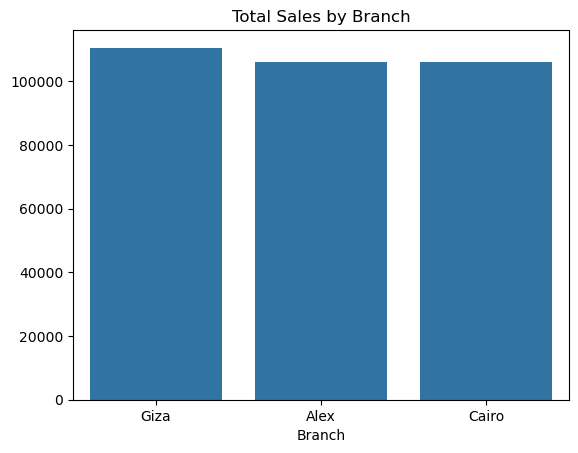

In [9]:
sns.barplot(x=branch_sales.index, y=branch_sales.values) 
plt.title("Total Sales by Branch")
plt.show()

## Product line which generates highest gross income

In [10]:
product_income = df.groupby('Product line')['gross income'].sum().sort_values(ascending=False)
print(product_income)

Product line
Food and beverages        2673.5640
Sports and travel         2624.8965
Electronic accessories    2587.5015
Fashion accessories       2585.9950
Home and lifestyle        2564.8530
Health and beauty         2342.5590
Name: gross income, dtype: float64


 #### The output shows that Food and beverages product line generates the highest gross income

## Visualizing the above output as a Bar Graph

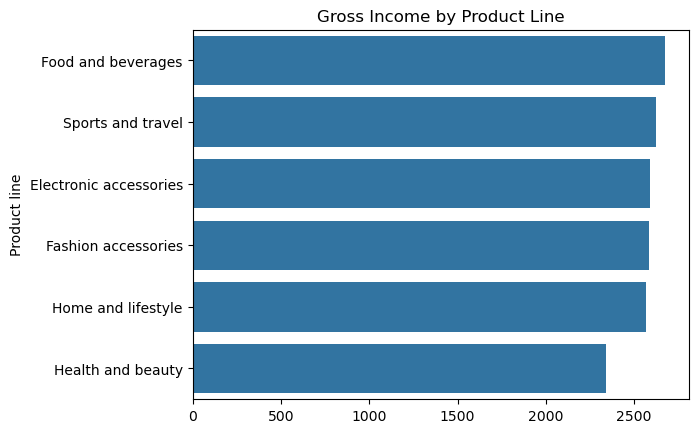

In [11]:
sns.barplot(x=product_income.values, y=product_income.index)
plt.title("Gross Income by Product Line")
plt.show()

## Customer Ratings Analysis

In [12]:
df["Rating"].mean()

np.float64(6.9727)

## Visualizing customer ratings on a histogram

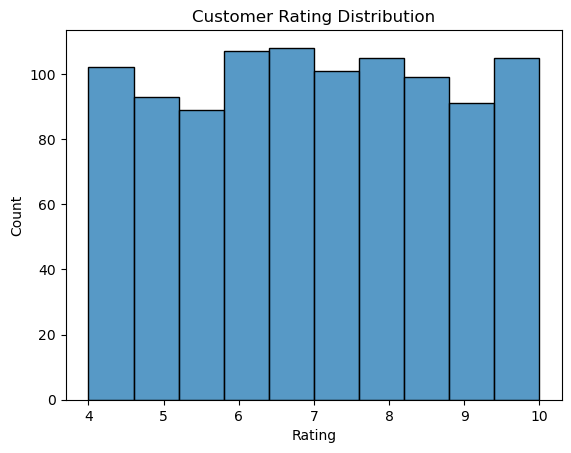

In [13]:
sns.histplot(df["Rating"], bins=10)
plt.title("Customer Rating Distribution")
plt.show()